In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/dataset.csv")

In [3]:
from preprocess_utils import preprocess_df
from feature_engineering import add_engineered_features, build_correlation_frame

df = preprocess_df(df)
df = add_engineered_features(df)

df[[
    "Body_Temperature",
    "Heart_Rate",
    "Duration_Days",
    "Temperature_Category",
    "Heart_Rate_Category",
    "Severity_Level"
]].head()


,Body_Temperature,Heart_Rate,Duration_Days,Temperature_Category,Heart_Rate_Category,Severity_Level
0,38.9,141.999125,4.0,Low,High,Severe
1,39.2,115.014160,4.0,Normal,Normal,Severe
2,39.1,110.001877,3.0,Normal,Normal,Moderate
3,40.0,78.006897,4.0,High,Low,Severe
4,39.4,124.998018,6.0,Normal,Normal,Moderate


# EDA:

In [4]:
df.head()

,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Appetite_Loss,...,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Prediction,Duration_Days,Temperature_Category,Heart_Rate_Category,Severity_Level
0,Cat,Persian,7,Female,4,Sneezing,Nasal Discharge,Eye Discharge,Lethargy,Yes,...,Yes,No,Yes,38.9,141.999125,Feline Upper Respiratory Infection,4.0,Low,High,Severe
1,Dog,Shih Tzu,4,Male,8,Lethargy,Vomiting,Loss Of Appetite,Fever,Yes,...,Yes,No,Yes,39.2,115.014160,Parvovirus,4.0,Normal,Normal,Severe
2,Dog,Chihuahua,4,Female,5,Lethargy,Vomiting,Loss Of Appetite,Fever,Yes,...,Yes,No,No,39.1,110.001877,Canine Parvovirus,3.0,Normal,Normal,Moderate
3,Sheep,Merino,4,Male,75,Coughing,Labored Breathing,Nasal Discharge,Fever,Yes,...,Yes,No,No,40.0,78.006897,Pneumonia,4.0,High,Low,Severe
4,Dog,German Shepherd,6,Female,30,Coughing,Labored Breathing,Lethargy,Loss Of Appetite,Yes,...,No,No,Yes,39.4,124.998018,Kennel Cough,6.0,Normal,Normal,Moderate


In [5]:
df.tail()

,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Appetite_Loss,...,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Prediction,Duration_Days,Temperature_Category,Heart_Rate_Category,Severity_Level
1495,Rabbit,English Angora,2,Male,1,Sneezing,Nasal Discharge,Loss Of Appetite,Fever,Yes,...,Yes,No,No,38.9,152.980819,Myxomatosis,3.0,Low,High,Moderate
1496,Cow,Ayrshire,3,Female,700,Coughing,Loss Of Appetite,Lethargy,Fever,Yes,...,No,Yes,Yes,39.4,90.011786,Bovine Respiratory Disease,5.0,Normal,Normal,Severe
1497,Rabbit,Mini Lop,1,Female,1,Sneezing,Loss Of Appetite,Nasal Discharge,Fever,Yes,...,Yes,No,No,38.8,158.011554,Myxomatosis,3.0,Low,High,Severe
1498,Sheep,Dorper,4,Male,95,Coughing,Loss Of Appetite,Lethargy,Fever,Yes,...,Yes,No,No,39.3,78.008368,Contagious Ecthyma,6.0,Normal,Low,Severe
1499,Dog,German Shepherd,3,Female,30,Lameness,Fever,Skin Lesions,Lethargy,Yes,...,Yes,No,No,39.3,110.010123,Lyme Disease,7.0,Normal,Normal,Moderate


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Animal_Type           1500 non-null   str    
 1   Breed                 1500 non-null   str    
 2   Age                   1500 non-null   int64  
 3   Gender                1500 non-null   str    
 4   Weight                1500 non-null   int64  
 5   Symptom_1             1500 non-null   str    
 6   Symptom_2             1500 non-null   str    
 7   Symptom_3             1500 non-null   str    
 8   Symptom_4             1500 non-null   str    
 9   Appetite_Loss         1500 non-null   str    
 10  Vomiting              1500 non-null   str    
 11  Diarrhea              1500 non-null   str    
 12  Coughing              1500 non-null   str    
 13  Labored_Breathing     1500 non-null   str    
 14  Lameness              1500 non-null   str    
 15  Skin_Lesions          1500 non-n

In [9]:
# df.value_counts()

In [8]:
df['Disease_Prediction'].value_counts()

Disease_Prediction
Bovine Tuberculosis               58
Bovine Respiratory Disease        53
Equine Influenza                  45
Swine Influenza                   45
Caprine Arthritis Encephalitis    42
                                  ..
Chronic Bronchitis                 1
Tuberculosis                       1
Cryptosporidiosis                  1
Goat Pox                           1
Respiratory Syncytial Virus        1
Name: count, Length: 136, dtype: int64

In [11]:
df.describe()

,Age,Weight,Body_Temperature,Heart_Rate,Duration_Days
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,5.022000,217.750000,39.299533,105.999000,4.974000
std,2.566562,260.348639,0.325838,27.913153,1.574477
min,1.000000,1.000000,38.400000,69.982485,1.000000
25%,3.000000,8.000000,39.100000,80.019476,4.000000
50%,5.000000,80.000000,39.300000,94.988214,5.000000
75%,6.000000,520.000000,39.500000,131.005186,6.000000
max,16.000000,850.000000,40.200000,165.000841,12.000000


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Weight'}>],
       [<Axes: title={'center': 'Body_Temperature'}>,
        <Axes: title={'center': 'Heart_Rate'}>],
       [<Axes: title={'center': 'Duration_Days'}>, <Axes: >]],
      dtype=object)

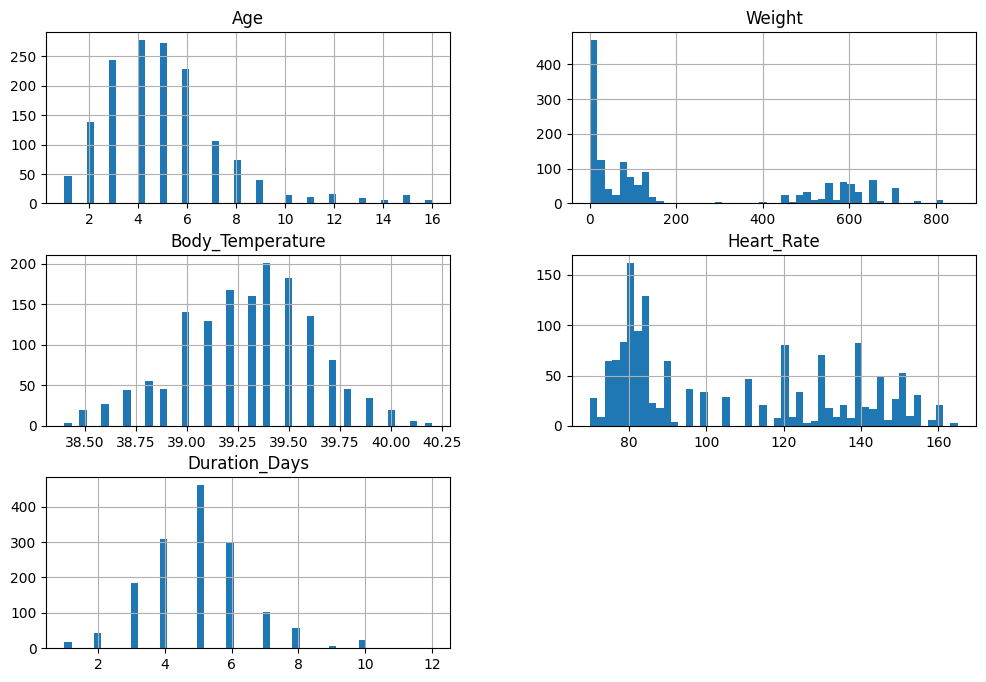

In [12]:
df.hist(bins = 50 , figsize = (12,8))

In [13]:
import numpy as np

def shuffle_and_split_data(data, test_ratio):
    np.random.seed(42)  # Set the seed for reproducibility
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

Text(0.5, 1.0, 'Heart Rate Distribution')

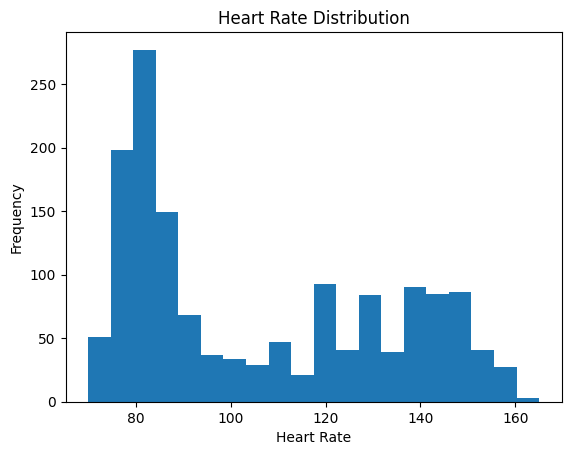

In [14]:
import matplotlib.pyplot as plt
plt.hist(df["Heart_Rate"], bins=20)
plt.xlabel("Heart Rate")
plt.ylabel("Frequency")
plt.title("Heart Rate Distribution")

In [17]:
import seaborn as sns

# plt.figure()
# sns.boxplot(x="Disease_Prediction", y="Heart_Rate", data=df)
# plt.xticks(rotation=90)
# plt.title("Heart Rate vs Disease")

Text(0.5, 1.0, 'Heart Rate vs Top 10 Diseases')

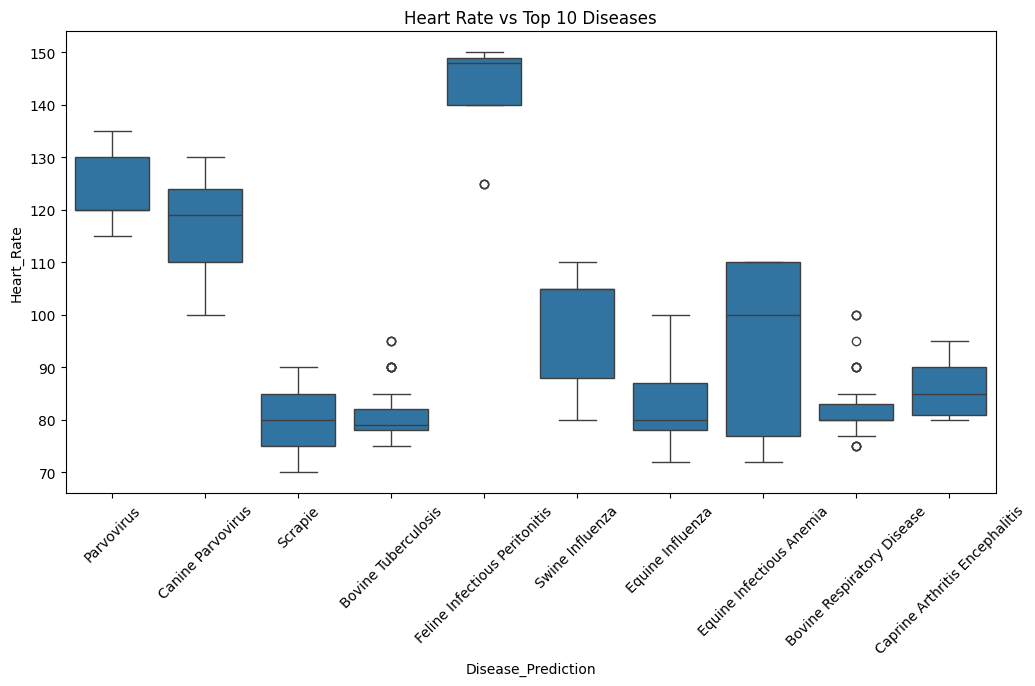

In [18]:
top_diseases = df["Disease_Prediction"].value_counts().nlargest(10).index

filtered_data = df[df["Disease_Prediction"].isin(top_diseases)]

plt.figure(figsize=(12,6))
sns.boxplot(x="Disease_Prediction", y="Heart_Rate", data=filtered_data)

plt.xticks(rotation=45)
plt.title("Heart Rate vs Top 10 Diseases")

Text(0.5, 1.0, 'Heart Rate vs Top Diseases')

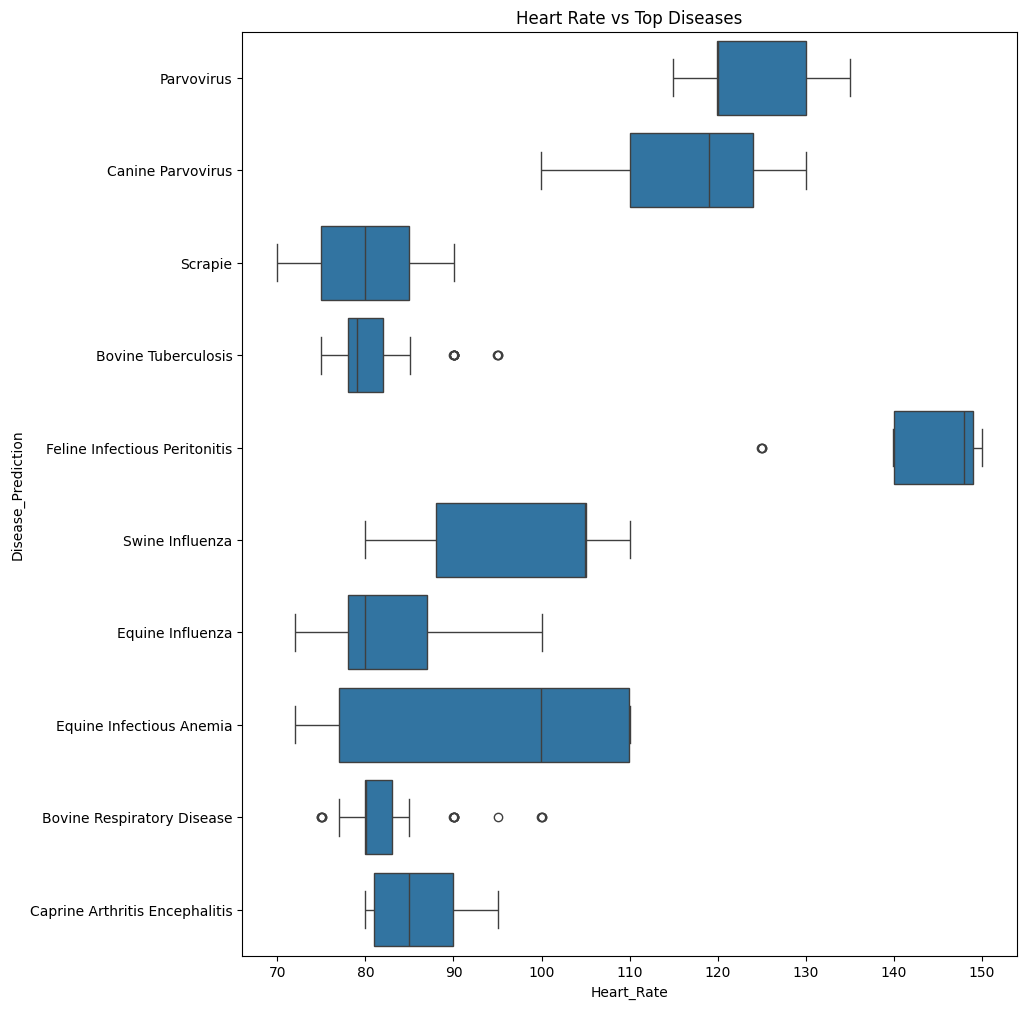

In [19]:
plt.figure(figsize=(10,12))

sns.boxplot(y="Disease_Prediction",
            x="Heart_Rate",
            data=filtered_data)

plt.title("Heart Rate vs Top Diseases")

In [20]:
print(df["Disease_Prediction"].value_counts()[df["Disease_Prediction"].value_counts() < 2])

Disease_Prediction
Inflammatory Bowel Disease     1
Goat Pox                       1
Cryptosporidiosis              1
Tuberculosis                   1
Chronic Bronchitis             1
Canine Heartworm Disease       1
Canine Influenza               1
Heartworm Disease              1
Respiratory Syncytial Virus    1
Name: count, dtype: int64


In [21]:
counts = df["Disease_Prediction"].value_counts()

df["Disease_Prediction"] = df["Disease_Prediction"].apply(
    lambda x: x if counts[x] > 2 else "Other"
)

In [22]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["Disease_Prediction"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

Text(0.5, 1.0, 'Top Diseases vs Heart Rate ')

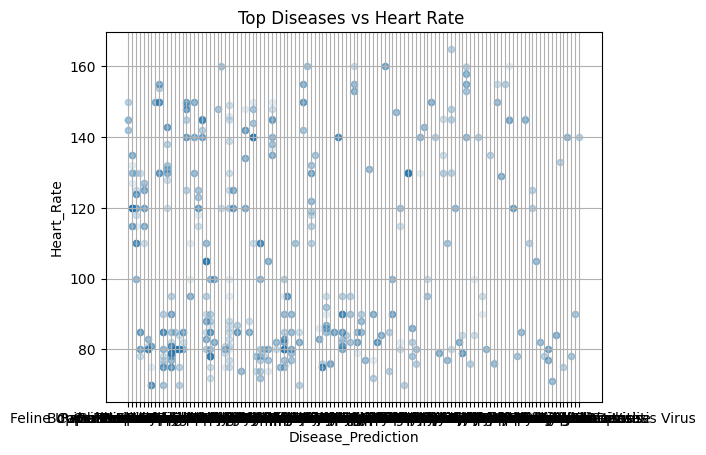

In [23]:
df.plot(kind="scatter", x="Disease_Prediction", y="Heart_Rate", alpha=0.1, grid=True)
plt.title("Top Diseases vs Heart Rate ")

In [24]:
import seaborn as sns

In [25]:
# print(sns.get_dataset_names())

Text(0.5, 1.0, 'Line Plot Example')

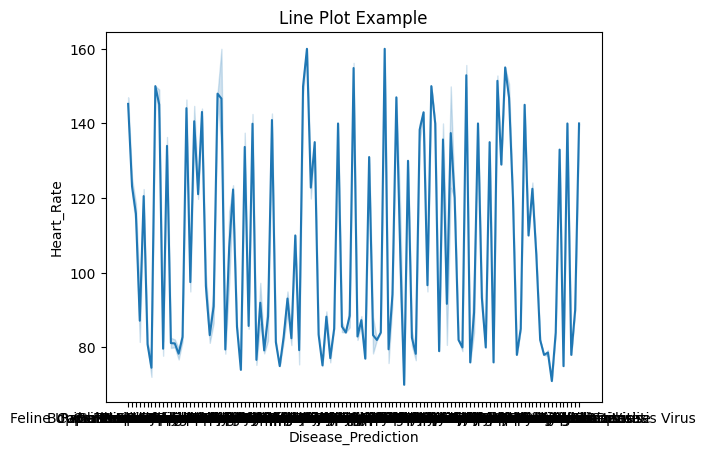

In [26]:
sns.lineplot(x="Disease_Prediction", y="Heart_Rate", data=df)
plt.title('Line Plot Example')

Text(0.5, 1.0, 'Scatter Plot Example')

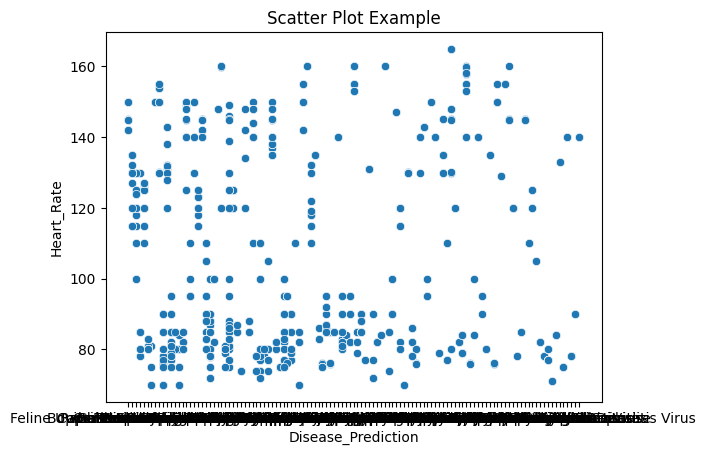

In [27]:
sns.scatterplot(x="Disease_Prediction", y="Heart_Rate", data=df)
plt.title('Scatter Plot Example')

Text(0.5, 1.0, 'Box Plot Example')

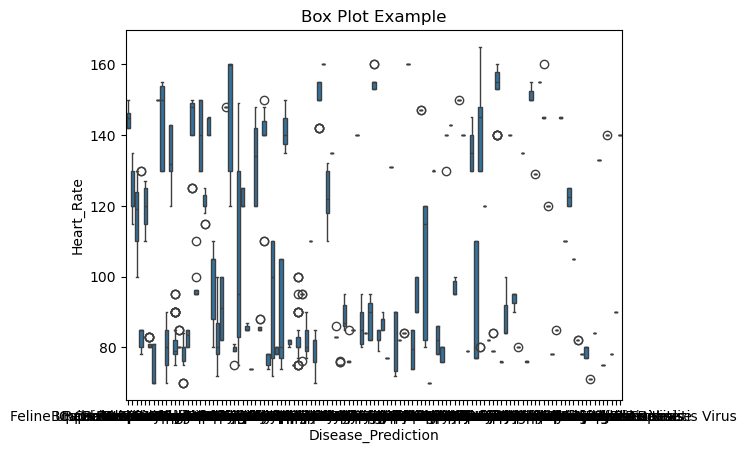

In [24]:
sns.boxplot(x="Disease_Prediction", y="Heart_Rate", data=df)
plt.title('Box Plot Example')

Text(0.5, 1.0, 'Percentage of Animals with Vomiting Symptoms')

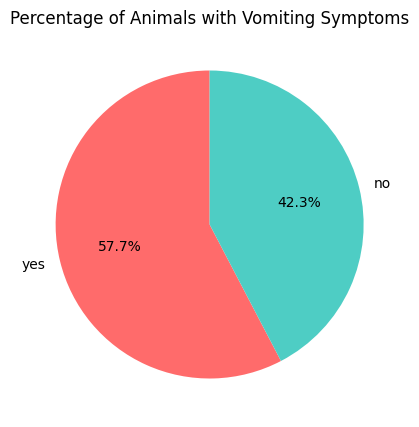

In [28]:
df['Vomiting'] = df['Vomiting'].str.lower().str.strip()

vomiting_counts = df['Vomiting'].value_counts()
vomiting_counts = vomiting_counts.loc[['yes', 'no']]  

plt.figure(figsize=(5, 5))
plt.pie(vomiting_counts, labels=vomiting_counts.index, autopct='%1.1f%%', startangle=90, colors=['#FF6B6B','#4ECDC4'])
plt.title('Percentage of Animals with Vomiting Symptoms')

Text(0.5, 1.0, 'Percentage of Animals with Appetite Loss Symptoms')

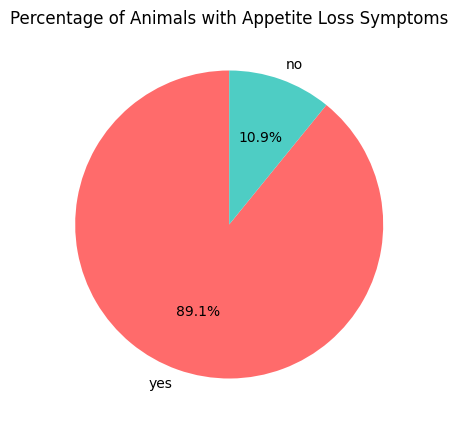

In [29]:
df['Appetite_Loss'] = df['Appetite_Loss'].str.lower().str.strip()

al_counts = df['Appetite_Loss'].value_counts()
al_counts = al_counts.loc[['yes', 'no']]  

plt.figure(figsize=(5, 5))
plt.pie(al_counts, labels=al_counts.index, autopct='%1.1f%%', startangle=90, colors=['#FF6B6B','#4ECDC4'])
plt.title('Percentage of Animals with Appetite Loss Symptoms')

Text(0.5, 1.0, 'Percentage of Animals with Coughing Loss Symptoms')

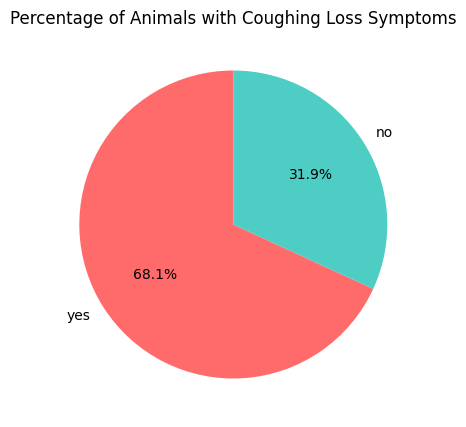

In [30]:
df['Coughing'] = df['Coughing'].str.lower().str.strip()

coughing_counts = df['Coughing'].value_counts()
coughing_counts = coughing_counts.loc[['yes', 'no']]  

plt.figure(figsize=(5, 5))
plt.pie(coughing_counts, labels=coughing_counts.index, autopct='%1.1f%%', startangle=90, colors=['#FF6B6B','#4ECDC4'])
plt.title('Percentage of Animals with Coughing Loss Symptoms')

Text(0.5, 1.0, 'Percentage of Animals with Diarrhea Symptoms')

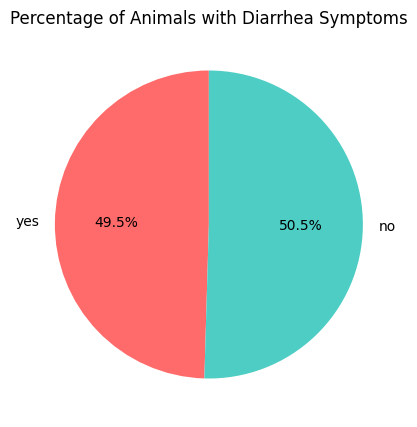

In [31]:
df['Diarrhea'] = df['Diarrhea'].str.lower().str.strip()

d_counts = df['Diarrhea'].value_counts()
d_counts = d_counts.loc[['yes', 'no']]  

plt.figure(figsize=(5, 5))
plt.pie(d_counts, labels=d_counts.index, autopct='%1.1f%%', startangle=90, colors=['#FF6B6B','#4ECDC4'])
plt.title('Percentage of Animals with Diarrhea Symptoms')

Text(0.5, 1.0, 'Percentage of Animals with Appetite Loss Symptoms')

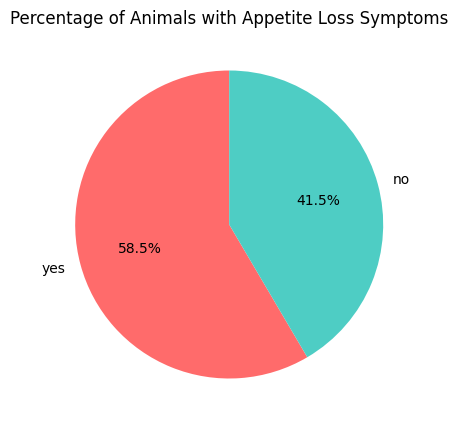

In [32]:
df['Lameness'] = df['Lameness'].str.lower().str.strip()

l_counts = df['Lameness'].value_counts()
l_counts = l_counts.loc[['yes', 'no']]  

plt.figure(figsize=(5, 5))
plt.pie(l_counts, labels=l_counts.index, autopct='%1.1f%%', startangle=90, colors=['#FF6B6B','#4ECDC4'])
plt.title('Percentage of Animals with Appetite Loss Symptoms')

Text(0.5, 1.0, 'Percentage of Animals with Appetite Loss Symptoms')

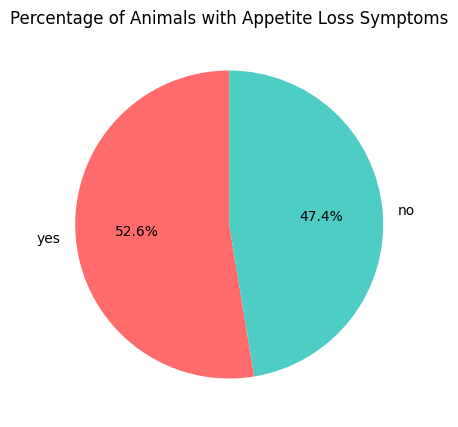

In [33]:
df['Labored_Breathing'] = df['Labored_Breathing'].str.lower().str.strip()

lb_counts = df['Labored_Breathing'].value_counts()
lb_counts = lb_counts.loc[['yes', 'no']]  

plt.figure(figsize=(5, 5))
plt.pie(lb_counts, labels=lb_counts.index, autopct='%1.1f%%', startangle=90, colors=['#FF6B6B','#4ECDC4'])
plt.title('Percentage of Animals with Appetite Loss Symptoms')

Text(0.5, 1.0, 'Percentage of Animals with Appetite Loss Symptoms')

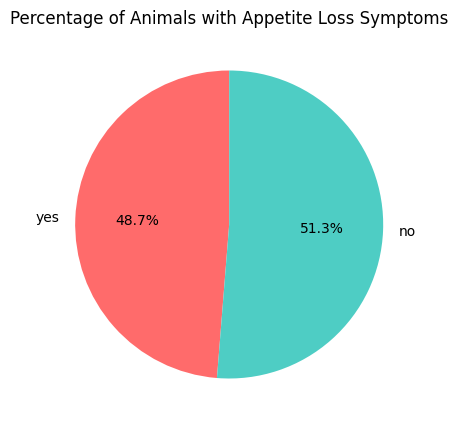

In [34]:
df['Nasal_Discharge'] = df['Nasal_Discharge'].str.lower().str.strip()

nd_counts = df['Nasal_Discharge'].value_counts()
nd_counts = nd_counts.loc[['yes', 'no']]  

plt.figure(figsize=(5, 5))
plt.pie(nd_counts, labels=nd_counts.index, autopct='%1.1f%%', startangle=90, colors=['#FF6B6B','#4ECDC4'])
plt.title('Percentage of Animals with Appetite Loss Symptoms')

Text(0.5, 1.0, 'Percentage of Animals with Appetite Loss Symptoms')

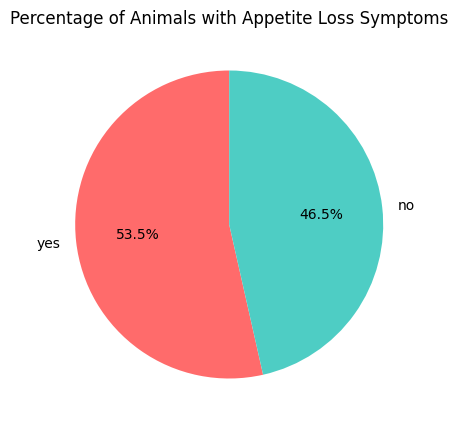

In [35]:
df['Eye_Discharge'] = df['Eye_Discharge'].str.lower().str.strip()

ed_counts = df['Eye_Discharge'].value_counts()
ed_counts = ed_counts.loc[['yes', 'no']]  

plt.figure(figsize=(5, 5))
plt.pie(ed_counts, labels=ed_counts.index, autopct='%1.1f%%', startangle=90, colors=['#FF6B6B','#4ECDC4'])
plt.title('Percentage of Animals with Appetite Loss Symptoms')

Text(0.5, 1.0, 'Percentage of Animals with Appetite Loss Symptoms')

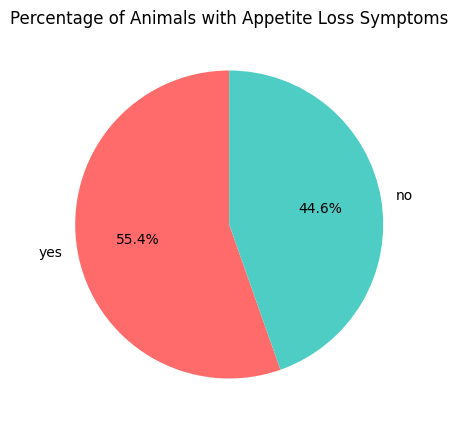

In [36]:
df['Skin_Lesions'] = df['Skin_Lesions'].str.lower().str.strip()

sl_counts = df['Skin_Lesions'].value_counts()
sl_counts = sl_counts.loc[['yes', 'no']]  

plt.figure(figsize=(5, 5))
plt.pie(sl_counts, labels=sl_counts.index, autopct='%1.1f%%', startangle=90, colors=['#FF6B6B','#4ECDC4'])
plt.title('Percentage of Animals with Appetite Loss Symptoms')

In [38]:
df.drop(columns=['Breed','Symptom_1','Symptom_2','Symptom_3','Symptom_4',"Disease_Prediction"],inplace=True)

In [39]:
df[["Severity_Level", "Temperature_Category", "Heart_Rate_Category"]].apply(pd.Series.value_counts).fillna(0).astype(int)


,Severity_Level,Temperature_Category,Heart_Rate_Category
High,0,325,413
Low,0,195,312
Mild,23,0,0
Moderate,434,0,0
Normal,0,980,775
Severe,1043,0,0


In [40]:
df['Gender']=df['Gender'].map({'Male':0,'Female':1})

In [41]:
df.head()

,Animal_Type,Age,Gender,Weight,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Duration_Days,Temperature_Category,Heart_Rate_Category,Severity_Level
0,0,7,1,4,yes,no,no,yes,yes,no,yes,no,yes,38.9,141.999125,4.0,Low,High,Severe
1,2,4,0,8,yes,yes,yes,yes,no,no,yes,no,yes,39.2,115.014160,4.0,Normal,Normal,Severe
2,2,4,1,5,yes,yes,no,yes,yes,yes,yes,no,no,39.1,110.001877,3.0,Normal,Normal,Moderate
3,7,4,0,75,yes,no,no,yes,no,yes,yes,no,no,40.0,78.006897,4.0,High,Low,Severe
4,2,6,1,30,yes,no,yes,no,yes,no,no,no,yes,39.4,124.998018,6.0,Normal,Normal,Moderate


In [42]:
df['Appetite_Loss']=df['Appetite_Loss'].map({'no':0,'yes':1})
df['Vomiting']=df['Vomiting'].map({'no':0,'yes':1})
df['Diarrhea']=df['Diarrhea'].map({'no':0,'yes':1})
df['Coughing']=df['Coughing'].map({'no':0,'yes':1})
df['Labored_Breathing']=df['Labored_Breathing'].map({'no':0,'yes':1})
df['Lameness']=df['Lameness'].map({'no':0,'yes':1})
df['Skin_Lesions']=df['Skin_Lesions'].map({'no':0,'yes':1})
df['Nasal_Discharge']=df['Nasal_Discharge'].map({'no':0,'yes':1})
df['Eye_Discharge']=df['Eye_Discharge'].map({'no':0,'yes':1})

In [43]:
df.head()

,Animal_Type,Age,Gender,Weight,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Duration_Days,Temperature_Category,Heart_Rate_Category,Severity_Level
0,0,7,1,4,1,0,0,1,1,0,1,0,1,38.9,141.999125,4.0,Low,High,Severe
1,2,4,0,8,1,1,1,1,0,0,1,0,1,39.2,115.014160,4.0,Normal,Normal,Severe
2,2,4,1,5,1,1,0,1,1,1,1,0,0,39.1,110.001877,3.0,Normal,Normal,Moderate
3,7,4,0,75,1,0,0,1,0,1,1,0,0,40.0,78.006897,4.0,High,Low,Severe
4,2,6,1,30,1,0,1,0,1,0,0,0,1,39.4,124.998018,6.0,Normal,Normal,Moderate


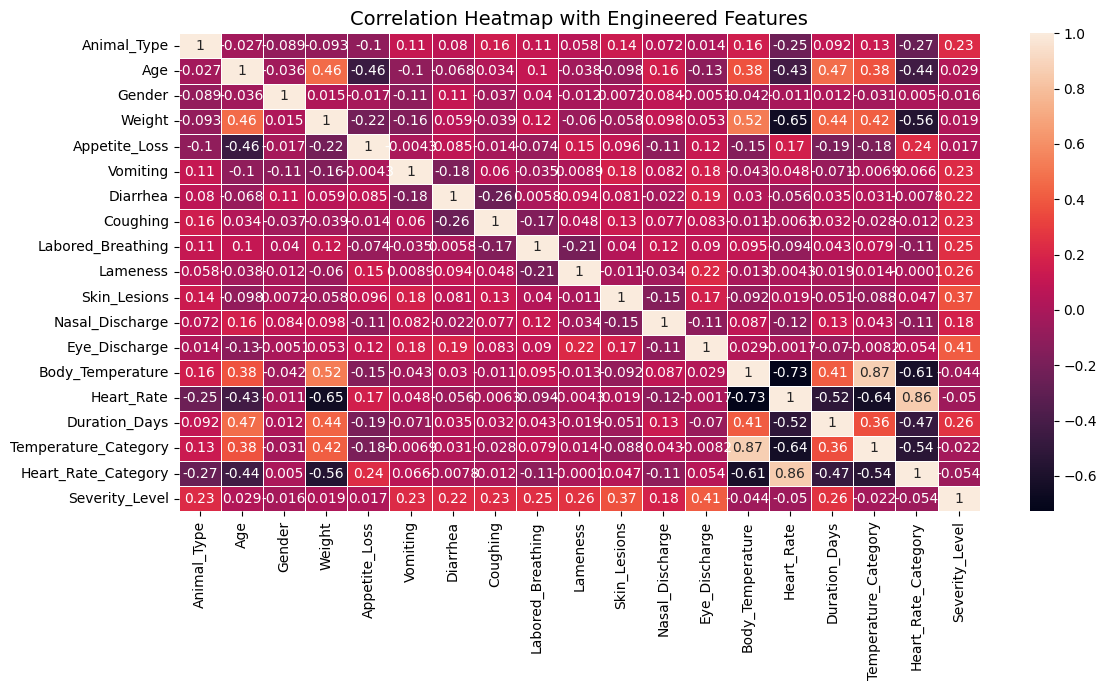

In [44]:
import seaborn as sns

correlation_df = build_correlation_frame(df)
numeric_corr = correlation_df.select_dtypes(include=['number'])
corr_matrix = numeric_corr.corr()

plt.figure(figsize=(12, 7))
sns.heatmap(corr_matrix, annot=True, linewidths=0.5)
plt.title('Correlation Heatmap with Engineered Features', fontsize=14)
plt.tight_layout()
